In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

np.random.seed(0)
%config InlineBackend.figure_format = 'retina'

df = pd.read_csv('data/prostate.data', sep='\t', header=0, index_col=0)
df_train = df[df['train'] == 'T'].drop(columns='train')
df_test = df[df['train'] == 'F'].drop(columns='train')

x_all = df.values[:,:-2]
x_train = df_train.values[:, :-1]
y_train = df_train.values[:,-1]
x_test = df_test.values[:, :-1]
y_test = df_test.values[:,-1]

Table 3.1

In [3]:
df_corr = df_train.drop(columns='lpsa').corr()
mask = np.tril(np.ones_like(df_corr.values), k=-1).astype(bool)
df_corr.where(mask).iloc[1:, :-1].style.format('{:.3f}', na_rep='')

,lcavol,lweight,age,lbph,svi,lcp,gleason
lweight,0.300,,,,,,
age,0.286,0.317,,,,,
lbph,0.063,0.437,0.287,,,,
svi,0.593,0.181,0.129,-0.139,,,
lcp,0.692,0.157,0.173,-0.089,0.671,,
gleason,0.426,0.024,0.366,0.033,0.307,0.476,
pgg45,0.483,0.074,0.276,-0.030,0.481,0.663,0.757


Figure 1

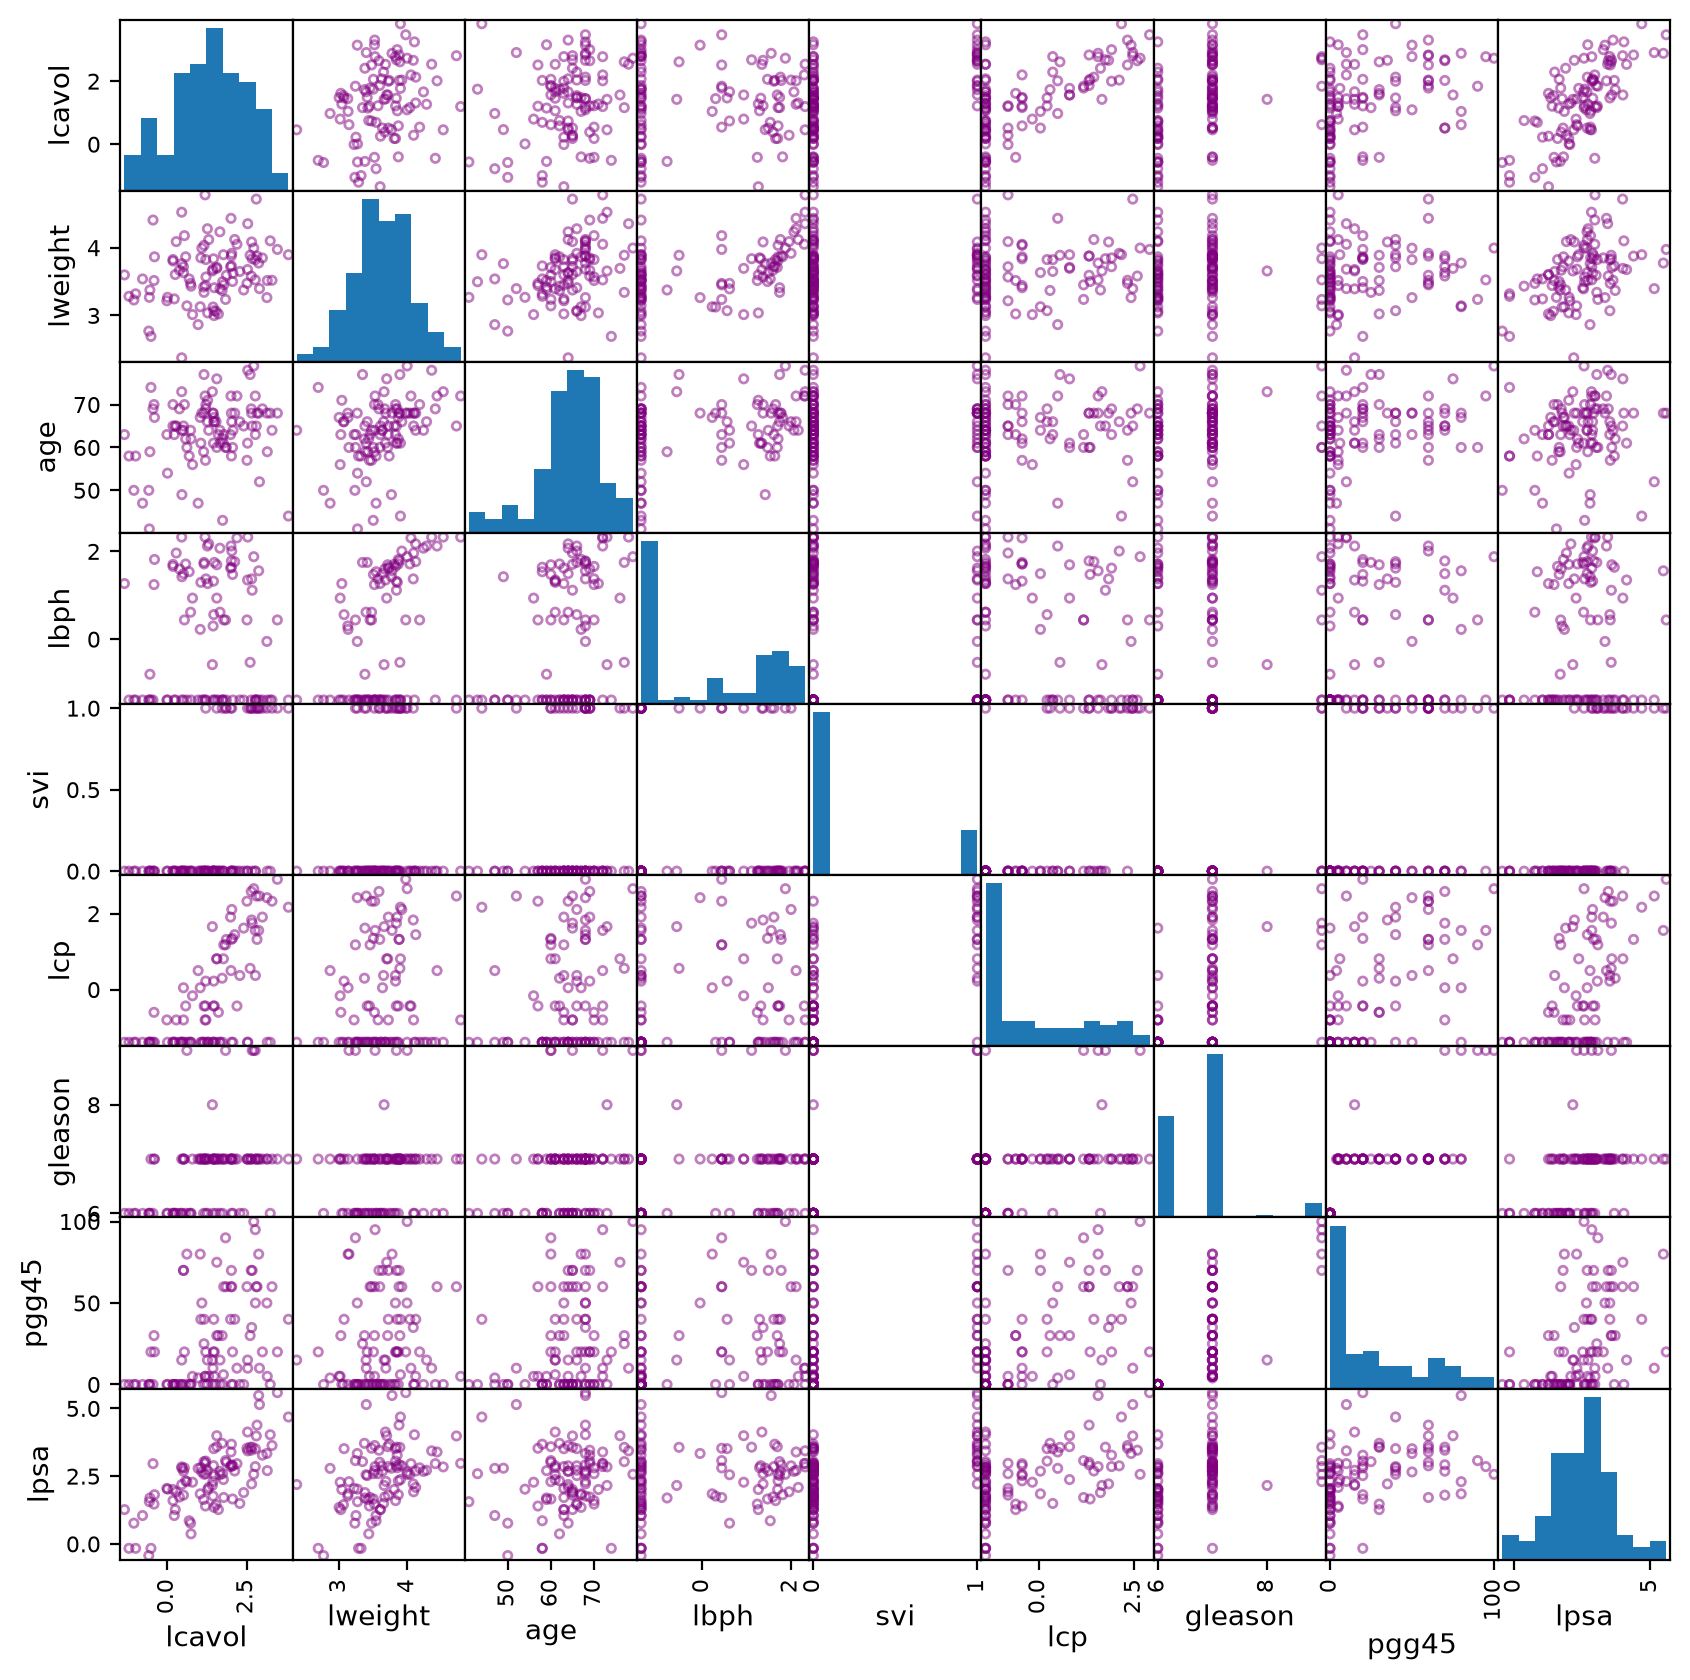

In [4]:
cols_x = ['lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45']
cols = cols_x + ['lpsa']
axes = pd.plotting.scatter_matrix(df[cols], figsize=(10,10), facecolors='none', edgecolors='purple')

Table 3.2

In [20]:
s = StandardScaler().fit(x_all)
x_train_std = sm.add_constant(s.transform(x_train))

m = sm.OLS(y_train, x_train_std).fit()

print(f'{"Term":>10s}{"Coefficient":>14s}{"Std. Error":>12s}{"Z Score":>9s}')
for a,b,c,d in zip(['intercept'] + cols_x, m.params, m.bse,m.tvalues):
    print(f"{a:>10s}{b:>14.2f}{c:12.2f}{d:9.2f}")

      Term   Coefficient  Std. Error  Z Score
 intercept          2.46        0.09    27.60
    lcavol          0.68        0.13     5.37
   lweight          0.26        0.10     2.75
       age         -0.14        0.10    -1.40
      lbph          0.21        0.10     2.06
       svi          0.30        0.12     2.47
       lcp         -0.29        0.15    -1.87
   gleason         -0.02        0.14    -0.15
     pgg45          0.27        0.15     1.74


Table 3.2 (corrected)

In [21]:
s = StandardScaler().fit(x_train)
x_train_std = sm.add_constant(s.transform(x_train))
x_test_std = sm.add_constant(s.transform(x_test))


m = sm.OLS(y_train, x_train_std).fit()

print(f'{"Term":>10s}{"Coefficient":>14s}{"Std. Error":>12s}{"Z Score":>9s}')
for a,b,c,d in zip(['intercept'] + cols_x, m.params, m.bse,m.tvalues):
    print(f"{a:>10s}{b:>14.2f}{c:12.2f}{d:9.2f}")

      Term   Coefficient  Std. Error  Z Score
 intercept          2.45        0.09    28.18
    lcavol          0.71        0.13     5.37
   lweight          0.29        0.11     2.75
       age         -0.14        0.10    -1.40
      lbph          0.21        0.10     2.06
       svi          0.31        0.12     2.47
       lcp         -0.29        0.15    -1.87
   gleason         -0.02        0.14    -0.15
     pgg45          0.28        0.16     1.74


In [22]:
x_reduced = x_train_std[:, [0, 1, 2,  4, 5]]
m_reduced = sm.OLS(y_train, x_reduced).fit()
f_stat, p_value, df_diff = m.compare_f_test(m_reduced)
print(f"F = {f_stat:.2f}, p = {p_value:.2f}")

F = 1.67, p = 0.17


Compare OLS vs MeanValue

In [ ]:
y_test_pred = m.predict(x_test_std)
y_base_pred = np.full_like(y_test, y_train.mean())

print(mean_squared_error(y_test, y_test_pred))
print(mean_squared_error(y_test, y_base_pred))

0.5212740055076004
1.0567332280603818
